In [4]:
is_nucleus = False

In [5]:
import pandas as pd
import torch
from scipy.stats import entropy
import transformers
import numpy as np
import json
from transformers import AutoTokenizer, AutoModelForCausalLM,AutoConfig
import sys
sys.path.append("./xai_scripts/tkn_coerce/")
from log_attr_scores import ProbabilisticAttributionScores
import os
import re
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import HTML
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

In [ ]:
def print_sentence_scores(sentence, scores, cmap = plt.cm.coolwarm , vmin= -1, vmax=1, legend=True, end="\n", show_plot = True):

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    cmap = cmap

    hex_colors = []
    
    colored_words = []
    for word, score in zip(sentence, scores):
        rgba = list(cmap(norm(score)))
        
        hex_color = mpl.colors.rgb2hex(rgba) # Convert RGBA to hex
        hex_color = hex_color#+"99"

        hex_colors.append(hex_color)
        
        colored_words.append(f"<span style='background-color:{hex_color}; font-size:18px; font-weight:regular; color:black; padding:2px;'>{word}</span>")
    
    html_sentence = " ".join(colored_words)
    if show_plot:
        display(HTML(html_sentence))
        if legend:
            fig, ax = plt.subplots(figsize=(3.5, 0.1))
            cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal')
            cb.set_label("Clamped LPAS Score", fontsize=8)
            cb.ax.tick_params(labelsize=6)
        print(end=end)
        plt.show()
        
    else:
        return hex_colors, cmap, norm

In [ ]:
if is_nucleus:
    path_ = "./xai_scripts/results/one_shot_nucleus/"
    path_new_anums = "TOPP_NEW_ANUMs"
else:
    path_ = "./xai_scripts/results/one_shot/"
path = os.path.join(path_, "torch_tensors/")


In [8]:
models_ = !ls ./xai_scripts/results/one_shot/ALLENAI_*
models_ = Counter(["_".join(i.split("ALLENAI_")[-1].split(".csv")[0].split("_")[:-1]) for i in models_])
all_models = [k for k,v in models_.items() if v==7]
all_models

['gemma-3-1b-it',
 'gemma-3-270m',
 'gpt2',
 'gpt-neo-1.3B',
 'Llama-3.2-1B-Instruct',
 'MobileLLM-R1-950M',
 'OLMo-2-0425-1B',
 'OLMo-2-0425-1B-Instruct',
 'Qwen2.5-1.5B-Instruct']

In [9]:
model_saves_names_dict = {'gemma-3-1b-it': 'google/gemma-3-1b-it' ,
 'gemma-3-270m':"google/gemma-3-270m",
 'gpt2': "openai-community/gpt2",
 'gpt-neo-1.3B': "EleutherAI/gpt-neo-1.3B",
 'Llama-3.2-1B-Instruct': "meta-llama/Llama-3.2-1B-Instruct",
 'MobileLLM-R1-950M': "facebook/MobileLLM-R1-950M",
 'OLMo-2-0425-1B': 'allenai/OLMo-2-0425-1B',
 'OLMo-2-0425-1B-Instruct':'allenai/OLMo-2-0425-1B-Instruct',
 'Qwen2.5-1.5B-Instruct': 'Qwen/Qwen2.5-1.5B-Instruct'}

In [11]:
if is_nucleus:
    import pickle
    with open(os.path.join(path_, path_new_anums, "topp_anums_coerced_1.pkl"), "rb") as f:
        asc_dict = pickle.load(f)
    asc_dict

In [25]:
processin_models = all_models[2:4]
min_ds = [0] * len(processin_models)
max_ds = [0] * len(processin_models)

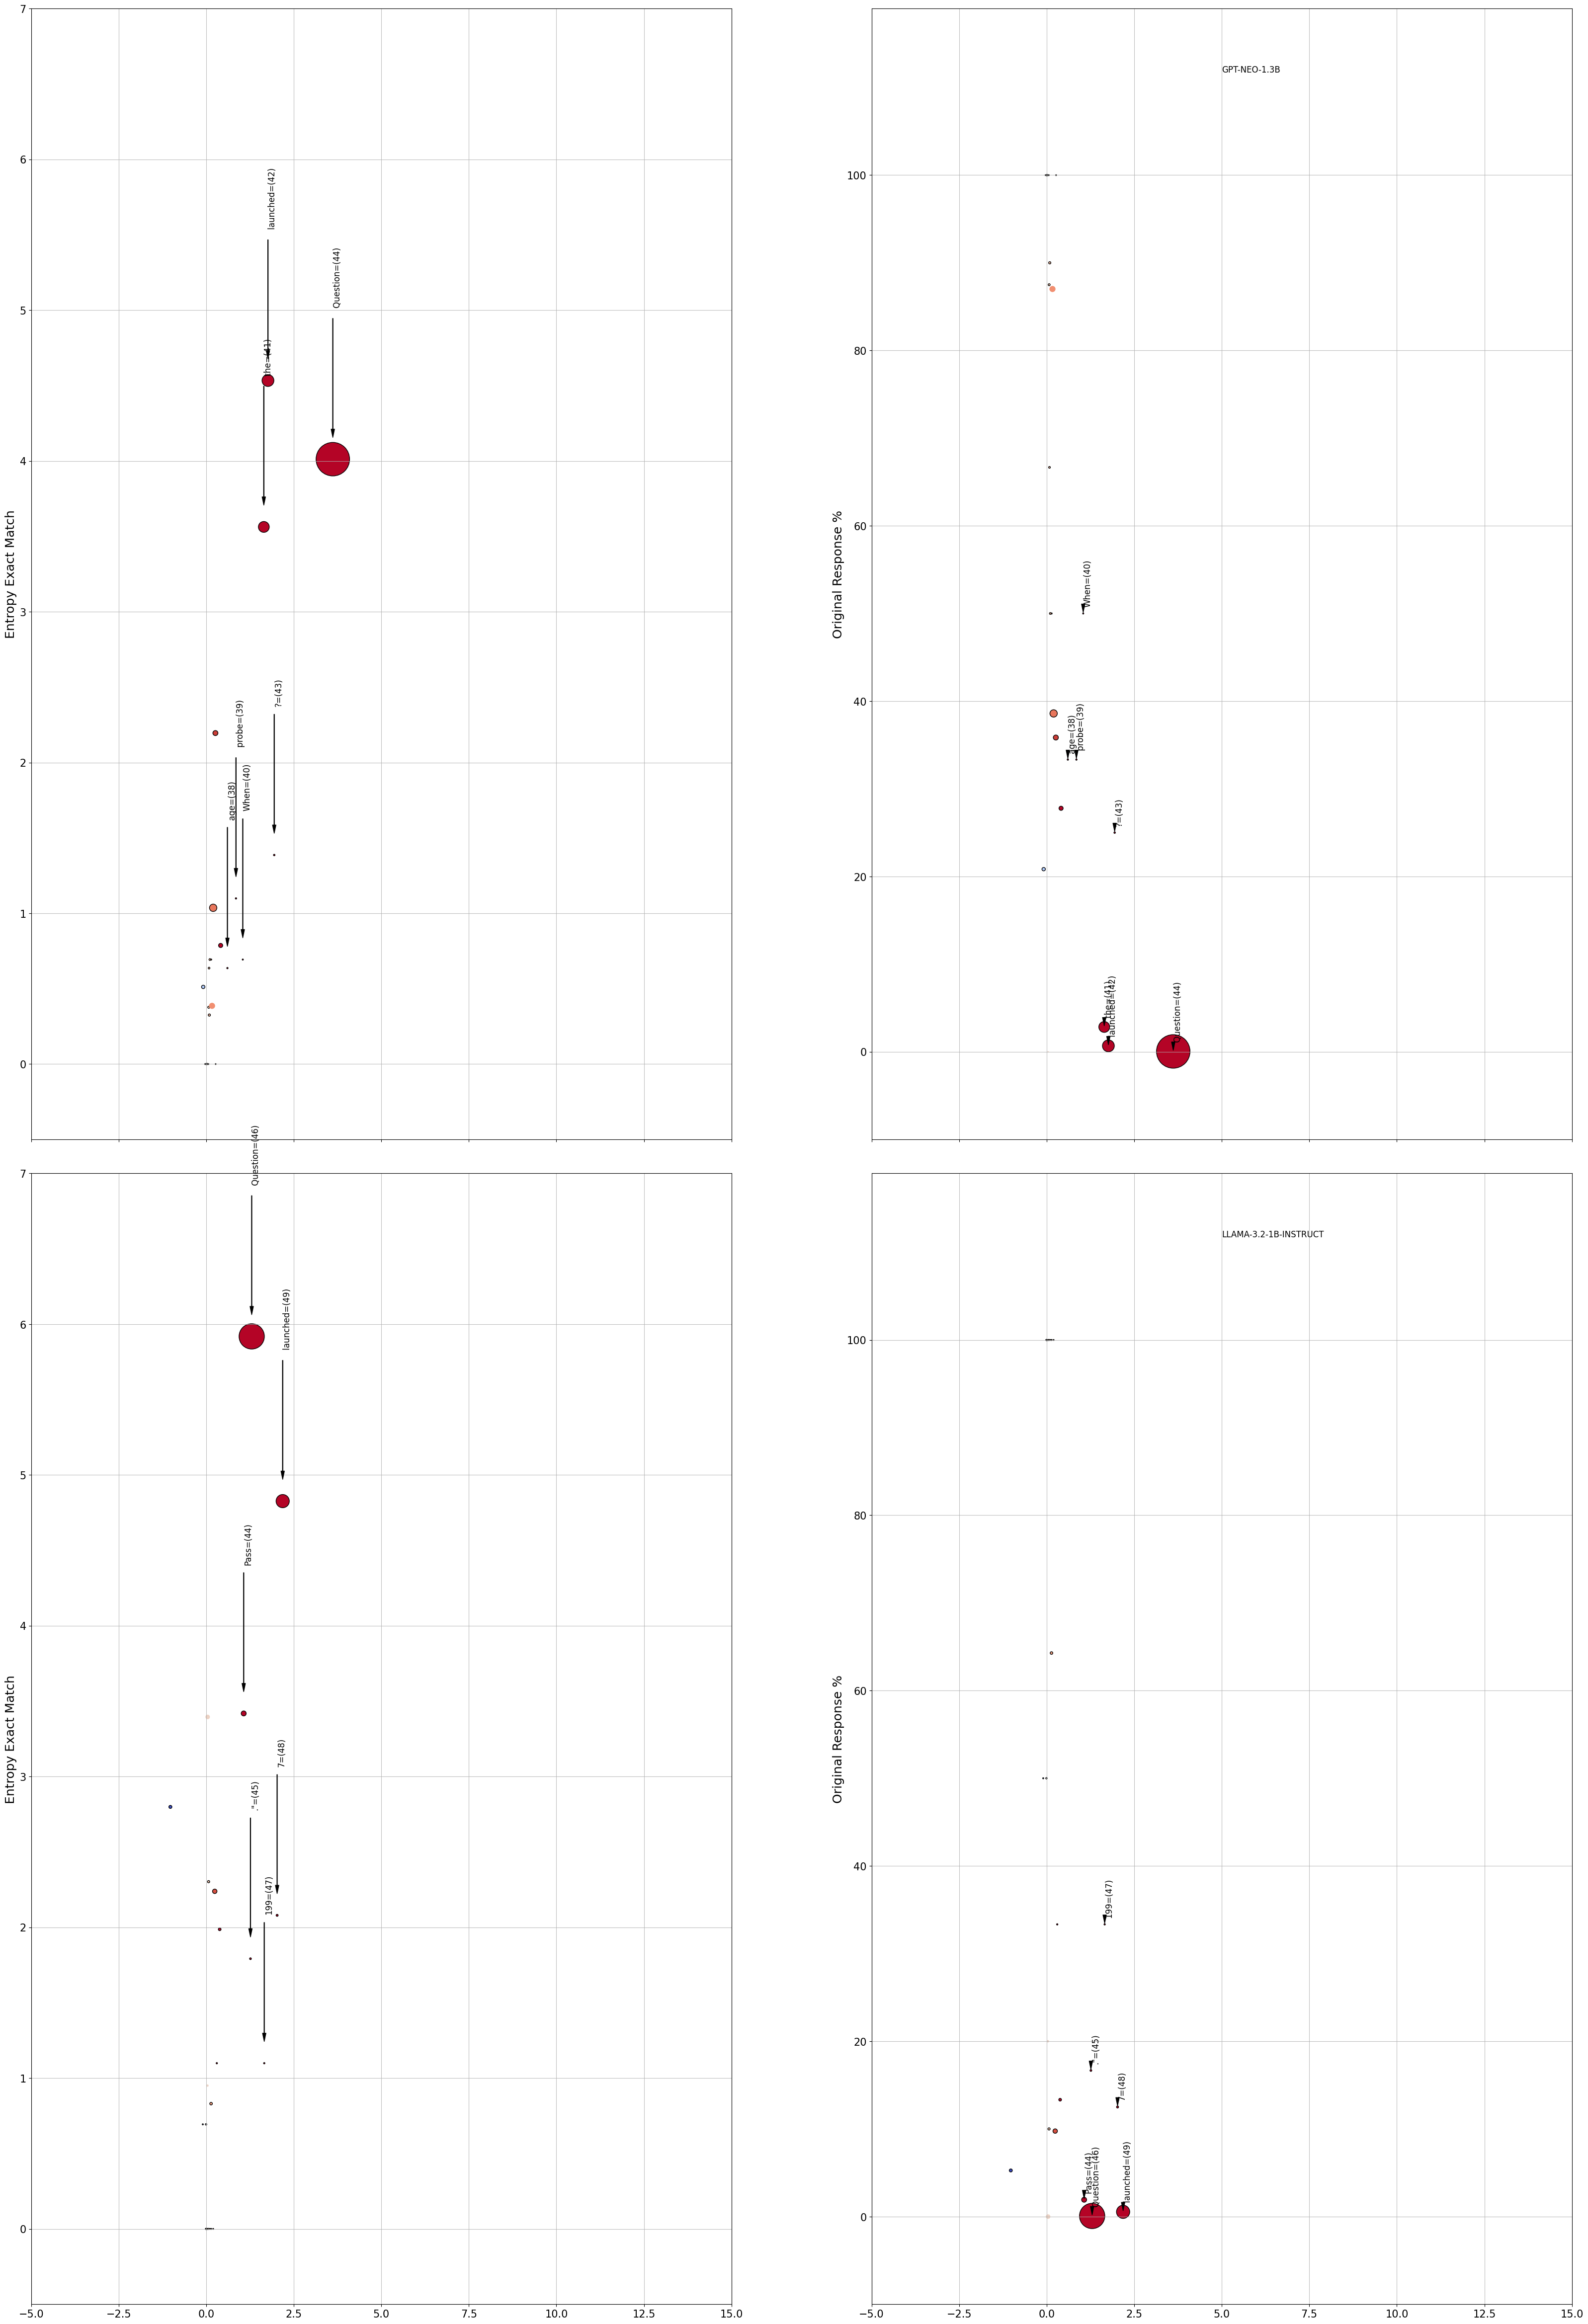

In [ ]:
min_asc = 100000
max_asc = -100000
min_ent = 100000
max_ent = -100000
xlow= -5

fig, axs = plt.subplots(len(processin_models), 2, sharex=True, figsize=(40,60))
fig.subplots_adjust(hspace=0.03) 

for ms_id, model_save in enumerate(processin_models):
    
    min_d = 100000
    max_d = -100000
    
    for file_id in [4]:
    
        model_name = model_saves_names_dict[model_save]
        path_model = os.path.join(path, model_save)


        s_id = file_id
        
        data_folder_muilf = f"ALLENAI_MUILF_{model_save}_MU.*_SID{s_id}.pt"
        data_folder_mulf = f"ALLENAI_MULF_{model_save}_MU.*_SID{s_id}.pt"
        data_folder_asc = f"ALLENAI_{model_save}_{s_id}.csv"
        
        
        with open( os.path.join(path_, data_folder_asc), "r") as f:
            lll_all = f.readlines()
            lll = [i.replace("<|endoftext|>", " endoftext ") for idx, i in enumerate(lll_all) if idx != 0 and "LogA" not in i]
            lll = [re.sub(r'\<\|([a-z\_]+)\|\>',r"<\1>", i) for i in lll]
            lines1 = [i.replace("\n", " ") for idd, i in enumerate(lll) if i != "\n" and len(i.split("|"))>7]
            if is_nucleus:
                linesD = [i.split("|")[5] for i in lines1[:]]
                lines = [float(asc_dict[model_save][s_id]) - float(ld) for ld in linesD]
            else:
                lines = [float(i.split("|")[-1].split("\n")[0]) for i in lines1[:]]#asc
            lines2 = [i.split("|")[4] for i in lines1[:]] #tkns
            D = [float(i.split("|")[-5]) for i in lines1[:]]
            min_d = min(min_d, min(D))
            max_d = max(max_d, max(D))
        
        filepaths_muilf = [i for i in os.listdir(path_model) if re.match(data_folder_muilf,i )]
        max_fp_muilf = max([int(ii.split("_")[-2].split("MU")[1]) for ii in filepaths_muilf])
        fp_muilf = [os.path.join(path_model, data_folder_muilf.replace(".*", str(i))) for i in range(max_fp_muilf + 1)]
        
        filepaths_mulf = [i for i in os.listdir(path_model) if re.match(data_folder_mulf,i )]
        max_fp_mulf = max([int(ii.split("_")[-2].split("MU")[1]) for ii in filepaths_mulf])
        fp_mulf = [os.path.join(path_model, data_folder_mulf.replace(".*", str(i))) for i in range(max_fp_mulf + 1)]
        
        ent_list = []
        ent_list_I = []
        scores = []
        for xid, x_no_resp in enumerate(fp_muilf):
            
            ent_resp = torch.load(fp_mulf[xid]) # with Response
            ent_no_resp = torch.load(x_no_resp) # does not contain Response 
        
            ent_num = torch.nn.functional.softmax( ent_resp - torch.max(ent_resp), dim = 0  ) 
            ent_denom = torch.nn.functional.softmax( ent_no_resp - torch.max(ent_no_resp), dim = 0) 
            
            ent_list.append(ent_num)
            ent_list_I.append(ent_denom) #without     
        
        pk_I = torch.stack(ent_list_I, dim = 0)
        pk = torch.stack(ent_list, dim = 0)
        H_I_ = entropy(pk_I.float().numpy(), axis=-1)
        H_I = H_I_ 
        H_ = entropy(pk.float().numpy(), axis=-1)
        H = H_ 
        
        asc = np.array(lines)
    
        assert(H.shape[0] == pk.shape[0])

        path_ent2 = os.path.join(path_,"entropy2_tkn", f'replacement_exact_P_I_PERC_oriresp_count_{model_save}*') 
        x = !ls $path_ent2
        replacement_ent_count_freqs_meteor_files = sorted(x)
        replacement_ent_count_freqs_meteor = np.load(replacement_ent_count_freqs_meteor_files[file_id])

        path_ent2 = os.path.join(path_,"entropy2_tkn", f'replacement_ent_P_I_PERC_count_freqs_{model_save}*') 
        replacement_ent_count_freqs_files = !ls $path_ent2
        replacement_ent_count_freqs_files = sorted(replacement_ent_count_freqs_files)
        replacement_ent_count_freqs = np.load(replacement_ent_count_freqs_files[file_id])
        path_ent2_count = os.path.join(path_,"entropy2_tkn", f'replacement_exact_P_I_PERC_count_{model_save}_{s_id}.npy') 
        path_ent2_oriTKN = os.path.join(path_,"entropy2_tkn", f'replacement_exact_P_I_PERC_oriTKN_count_{model_save}_{s_id}.npy') 

        ent2_count = np.load(path_ent2_count)
        ent2_oriTKN = np.load(path_ent2_oriTKN)

        assert len(lines2) == replacement_ent_count_freqs_meteor.shape[0] 
        assert len(lines2) == replacement_ent_count_freqs.shape[0]

        tuple_ent_meteor_asc = [*zip(lines, lines2, replacement_ent_count_freqs_meteor, replacement_ent_count_freqs, [*range(len(lines2))], ent2_count, ent2_oriTKN)]
        sorted_tuple_tuple_ent_meteor_asc = sorted(tuple_ent_meteor_asc, key=lambda x: x[0])


        max_y = 0.3
        min_y = -0.3
        s = 10
        
        
        replacement_ent_count_freqs_plot = [i[3] for i in sorted_tuple_tuple_ent_meteor_asc]
        replacement_ent_count_freqs_meteor_plot = [i[2] for i in sorted_tuple_tuple_ent_meteor_asc]
        replacement_ent_count90_plot = [i[5] for i in sorted_tuple_tuple_ent_meteor_asc]
        replacement_ent_oriTKN_count_plot = [i[6] for i in sorted_tuple_tuple_ent_meteor_asc]
        lines_plot  = [i[0] for i in sorted_tuple_tuple_ent_meteor_asc]
        lines2_plot = [i[1] for i in sorted_tuple_tuple_ent_meteor_asc]
        lines2_IDX_plot = [i[4] for i in sorted_tuple_tuple_ent_meteor_asc]
        asc_plot = np.array(lines_plot)

        ecolors, cbarMap, cbarNorm = print_sentence_scores(lines2, asc, vmin=min_y, vmax=max_y, show_plot=False)
        
        
        #regression line
        xc = asc_plot 
        min_asc = min(min_asc, min(asc_plot))
        max_asc = max(max_asc, max(asc_plot))
        
        m, b = np.polyfit(xc, replacement_ent_count_freqs_plot, 1)
        y_pred = [xc_ * m for xc_ in xc] + b
        
        ecolor = 'black'
        axs[ms_id, 0].scatter(xc, replacement_ent_count_freqs_plot, s=[jj+1 for jj in replacement_ent_count90_plot],  
                              marker='o', label="Entropy Exact Match", c=asc_plot, 
                              cmap=cbarMap, norm=cbarNorm, linewidths=[1 if jj > 1 else jj for jj in replacement_ent_oriTKN_count_plot], edgecolors="black")
        
        axs[ms_id, 0].grid(True, linestyle='-', alpha=0.8)
        axs[ms_id, 0].tick_params(axis='y', labelcolor="black", labelsize=15 )
        axs[ms_id, 0].tick_params(axis='x', labelcolor="black", labelsize=15 )
        axs[ms_id, 0].set_ylabel('Entropy Exact Match', color=ecolor,fontsize=18)
        axs[ms_id, 0].set_ylim(bottom=-0.5, top=7) 
        axs[ms_id, 0].set_xlim((xlow,15)) 


        min_ent = min(min_ent, min(replacement_ent_count_freqs_plot))
        max_ent = max(max_ent, max(replacement_ent_count_freqs_plot))


        xc = asc_plot #[*range(len(replacement_ent_count_freqs_plot))]
        min_asc = min(min_asc, min(asc_plot))
        max_asc = max(max_asc, max(asc_plot))
        
        m, b = np.polyfit(xc, replacement_ent_count_freqs_plot, 1)
        y_pred = [xc_ * m for xc_ in xc] + b

        repl_oriC_perc_of_ent2max90 = [0] * len(replacement_ent_count_freqs_meteor_plot)
        for iddd, (repl_oriC, ent2_count_max90) in  enumerate(zip(replacement_ent_count_freqs_meteor_plot,replacement_ent_count90_plot)):
            repl_oriC_perc_of_ent2max90[iddd] = (repl_oriC * 100)/ent2_count_max90
            
        
        ecolor = 'black'
        axs[ms_id, 1].scatter(xc, repl_oriC_perc_of_ent2max90, s=[jj+1 for jj in replacement_ent_count90_plot],  marker='o', 
                              label="Entropy Exact Match", c=asc_plot, cmap=cbarMap, norm=cbarNorm, 
                              linewidths=[1 if jj > 1 else jj for jj in replacement_ent_oriTKN_count_plot], edgecolors="black")
       
        axs[ms_id, 1].grid(True, linestyle='-', alpha=0.8)
        axs[ms_id, 1].tick_params(axis='y', labelcolor="black", labelsize=15 )
        axs[ms_id, 1].tick_params(axis='x', labelcolor="black", labelsize=15 )
        axs[ms_id, 1].set_ylabel('Original Response %', color=ecolor,fontsize=18)
        axs[ms_id, 1].set_ylim(bottom=-10, top=119) 
        axs[ms_id, 1].set_xlim((xlow,15)) 

        axs[ms_id, 1].text(0.5, 0.95, model_save.upper(),
            transform=axs[ms_id, 1].transAxes, 
            fontsize=12, fontweight="regular",
            va="top", ha="left", color="black")


    

        ##############################
        ### ANNOTATE HIGH ASC VALS
        ##############################
        for spos in np.where( xc>=0.5 )[0]:
            assert xc.shape[0] == len(lines2_plot)
            R_I = repl_oriC_perc_of_ent2max90
            if xc[spos] >= 0 :#and replacement_ent_count90_plot[spos]>500:
                yy = R_I[spos]
                axs[ms_id, 1].annotate(f"{lines2_plot[spos]}=({spos})", xy=(xc[spos], yy + 0.1 ), xytext=(xc[spos], yy+1),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=0.6, headwidth=5),
                             fontsize=12, rotation=90,color='black')

                yy = replacement_ent_count_freqs_plot[spos]
                axs[ms_id, 0].annotate(f"{lines2_plot[spos]}=({spos})", xy=(xc[spos], yy + 0.1 ), xytext=(xc[spos], yy+1),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=0.6, headwidth=5),
                             fontsize=12, rotation=90,color='black')

  
plt.show()
        
    


In [ ]:
%%time
def plot_all(all_models, ent_foler = "entropy2_tkn", s=0):
    min_asc = 100000
    max_asc = -100000
    min_ent = 100000
    max_ent = -100000
    
    xlow= -5
    
    fig, axs = plt.subplots(1, 2, sharex=True, figsize=(40,8))
    fig.subplots_adjust(hspace=0.03) 
    
    for model_save in all_models[:]:
        
        for file_id in range(7):
            # model_save= all_models[2]
            model_name = model_saves_names_dict[model_save]
            path_model = os.path.join(path, model_save)
    
    
            s_id = file_id
            
            data_folder_muilf = f"ALLENAI_MUILF_{model_save}_MU.*_SID{s_id}.pt"
            data_folder_mulf = f"ALLENAI_MULF_{model_save}_MU.*_SID{s_id}.pt"
            data_folder_asc = f"ALLENAI_{model_save}_{s_id}.csv"
            
            with open( os.path.join(path_, data_folder_asc), "r") as f:
                lll = [i.replace("<|endoftext|>", " endoftext ") for idx, i in enumerate(f.readlines()) if idx != 0 and "LogA" not in i]
                lll = [re.sub(r'\<\|([a-z\_]+)\|\>',r"<\1>", i) for i in lll]
                lines1 = [i.replace("\n", " ") for idd, i in enumerate(lll) if i != "\n" and len(i.split("|"))>7]
                if is_nucleus:
                    linesD = [i.split("|")[5] for i in lines1[:]]
                    lines = [float(asc_dict[model_save][s_id]) - float(ld) for ld in linesD]
                else:
                    lines = [float(i.split("|")[-1].split("\n")[0]) for i in lines1[:]]
                lines2 = [i.split("|")[4] for i in lines1[:]]
            
            
            filepaths_muilf = [i for i in os.listdir(path_model) if re.match(data_folder_muilf,i )]
            max_fp_muilf = max([int(ii.split("_")[-2].split("MU")[1]) for ii in filepaths_muilf])
            fp_muilf = [os.path.join(path_model, data_folder_muilf.replace(".*", str(i))) for i in range(max_fp_muilf + 1)]
            
            filepaths_mulf = [i for i in os.listdir(path_model) if re.match(data_folder_mulf,i )]
            max_fp_mulf = max([int(ii.split("_")[-2].split("MU")[1]) for ii in filepaths_mulf])
            fp_mulf = [os.path.join(path_model, data_folder_mulf.replace(".*", str(i))) for i in range(max_fp_mulf + 1)]
            
            ent_list = []
            ent_list_I = []
            scores = []
            for xid, x_no_resp in enumerate(fp_muilf):
                
                ent_resp = torch.load(fp_mulf[xid]) # with Response
                ent_no_resp = torch.load(x_no_resp) # does not contain Response 
            
                ent_num = torch.nn.functional.softmax( ent_resp - torch.max(ent_resp), dim = 0  ) 
                ent_denom = torch.nn.functional.softmax( ent_no_resp - torch.max(ent_no_resp), dim = 0) 
                
                ent_list.append(ent_num)
                ent_list_I.append(ent_denom) #without     
            
            pk_I = torch.stack(ent_list_I, dim = 0)
            pk = torch.stack(ent_list, dim = 0)
            H_I_ = entropy(pk_I.float().numpy(), axis=-1)
            H_I = H_I_ #np.nan_to_num(H_I_, nan=0.0)
            H_ = entropy(pk.float().numpy(), axis=-1)
            H = H_ #np.nan_to_num(H_, nan=0.0)
            
            asc = np.array(lines)
        
            assert(H.shape[0] == pk.shape[0])
    
            path_ent2 = os.path.join(path_,ent_foler, f'replacement_exact_P_I_PERC_oriresp_count_{model_save}*') 
            x = !ls $path_ent2
            replacement_ent_count_freqs_meteor_files = sorted(x)
            replacement_ent_count_freqs_meteor = np.load(replacement_ent_count_freqs_meteor_files[file_id])
    
            path_ent2 = os.path.join(path_,ent_foler, f'replacement_ent_P_I_PERC_count_freqs_{model_save}*') 
            replacement_ent_count_freqs_files = !ls $path_ent2
            replacement_ent_count_freqs_files = sorted(replacement_ent_count_freqs_files)
            replacement_ent_count_freqs = np.load(replacement_ent_count_freqs_files[file_id])
    
    
            path_ent2_count = os.path.join(path_,ent_foler, f'replacement_exact_P_I_PERC_count_{model_save}_{s_id}.npy') 
            path_ent2_oriTKN = os.path.join(path_,ent_foler, f'replacement_exact_P_I_PERC_oriTKN_count_{model_save}_{s_id}.npy') 
    
            ent2_count = np.load(path_ent2_count)
            ent2_oriTKN = np.load(path_ent2_oriTKN)
    
            assert len(lines2) == replacement_ent_count_freqs_meteor.shape[0] 
            assert len(lines2) == replacement_ent_count_freqs.shape[0]
    
            tuple_ent_meteor_asc = [*zip(lines, lines2, replacement_ent_count_freqs_meteor, replacement_ent_count_freqs, [*range(len(lines2))], ent2_count, ent2_oriTKN )]
            sorted_tuple_tuple_ent_meteor_asc = sorted(tuple_ent_meteor_asc, key=lambda x: x[0])
    
            max_y = 0.3
            min_y = -0.3
            s = 30
            
            replacement_ent_count_freqs_plot = [i[3] for i in sorted_tuple_tuple_ent_meteor_asc]
            replacement_ent_count_freqs_meteor_plot = [i[2] for i in sorted_tuple_tuple_ent_meteor_asc]
            replacement_ent_count90_plot = [i[5] for i in sorted_tuple_tuple_ent_meteor_asc]
            replacement_ent_oriTKN_count_plot = [i[6] for i in sorted_tuple_tuple_ent_meteor_asc]
            lines_plot  = [i[0] for i in sorted_tuple_tuple_ent_meteor_asc]
            lines2_plot = [i[1] for i in sorted_tuple_tuple_ent_meteor_asc]
            lines2_IDX_plot = [i[4] for i in sorted_tuple_tuple_ent_meteor_asc]
            asc_plot = np.array(lines_plot)
    
            ecolors, cbarMap, cbarNorm = print_sentence_scores(lines2, asc, vmin=min_y, vmax=max_y, show_plot=False)
            
            #regression line
            xc = asc_plot 
            min_asc = min(min_asc, min(asc_plot))
            max_asc = max(max_asc, max(asc_plot))
            
            m, b = np.polyfit(xc, replacement_ent_count_freqs_plot, 1)
            y_pred = [xc_ * m for xc_ in xc] + b
            
            ecolor = 'black'
            
            axs[0].scatter(xc, replacement_ent_count_freqs_plot, s=replacement_ent_count90_plot if s==0 else None,  
                           marker='o', label="Entropy Exact Match", c=asc_plot, cmap=cbarMap, norm=cbarNorm, 
                           linewidths=0.7, edgecolors="black")
            
            axs[0].grid(True, linestyle='-', alpha=0.8)
            axs[0].tick_params(axis='y', labelcolor="black", labelsize=15 )
            axs[0].tick_params(axis='x', labelcolor="black", labelsize=15 )
            axs[0].set_ylabel('Entropy Exact Match', color=ecolor,fontsize=18)
            axs[0].set_ylim(bottom=-0.5, top=6.5) 
            axs[0].set_xlim((xlow,15)) 
    
           
            min_ent = min(min_ent, min(replacement_ent_count_freqs_plot))
            max_ent = max(max_ent, max(replacement_ent_count_freqs_plot))
    
    
            xc = asc_plot 
            min_asc = min(min_asc, min(asc_plot))
            max_asc = max(max_asc, max(asc_plot))
            
            m, b = np.polyfit(xc, replacement_ent_count_freqs_plot, 1)
            y_pred = [xc_ * m for xc_ in xc] + b
    
            repl_oriC_perc_of_ent2max90 = [0] * len(replacement_ent_count_freqs_meteor_plot)
            for iddd, (repl_oriC, ent2_count_max90) in  enumerate(zip(replacement_ent_count_freqs_meteor_plot,replacement_ent_count90_plot)):
                repl_oriC_perc_of_ent2max90[iddd] = (repl_oriC * 100)/ent2_count_max90
                
            
            ecolor = 'black'
          
            axs[1].scatter(xc, repl_oriC_perc_of_ent2max90, s=[ jj+1 for jj in replacement_ent_count90_plot],  marker='o', 
                           label="Entropy Exact Match", c=asc_plot, cmap=cbarMap, norm=cbarNorm, 
                           linewidths=[1 if jjj > 1 else jjj for jjj in replacement_ent_oriTKN_count_plot], edgecolors='black', alpha=0.7)
           
            axs[1].grid(True, linestyle='-', alpha=0.8)
            axs[1].tick_params(axis='y', labelcolor="black", labelsize=30 )
            axs[1].tick_params(axis='x', labelcolor="black", labelsize=30 )
            axs[1].set_ylabel('Original Response %', color=ecolor,fontsize=25)
            axs[1].set_ylim(bottom=-10, top=119) 
            axs[1].set_xlim((xlow,15)) 
            
 
    plt.show()
            
                        
              
        


CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 11.9 μs


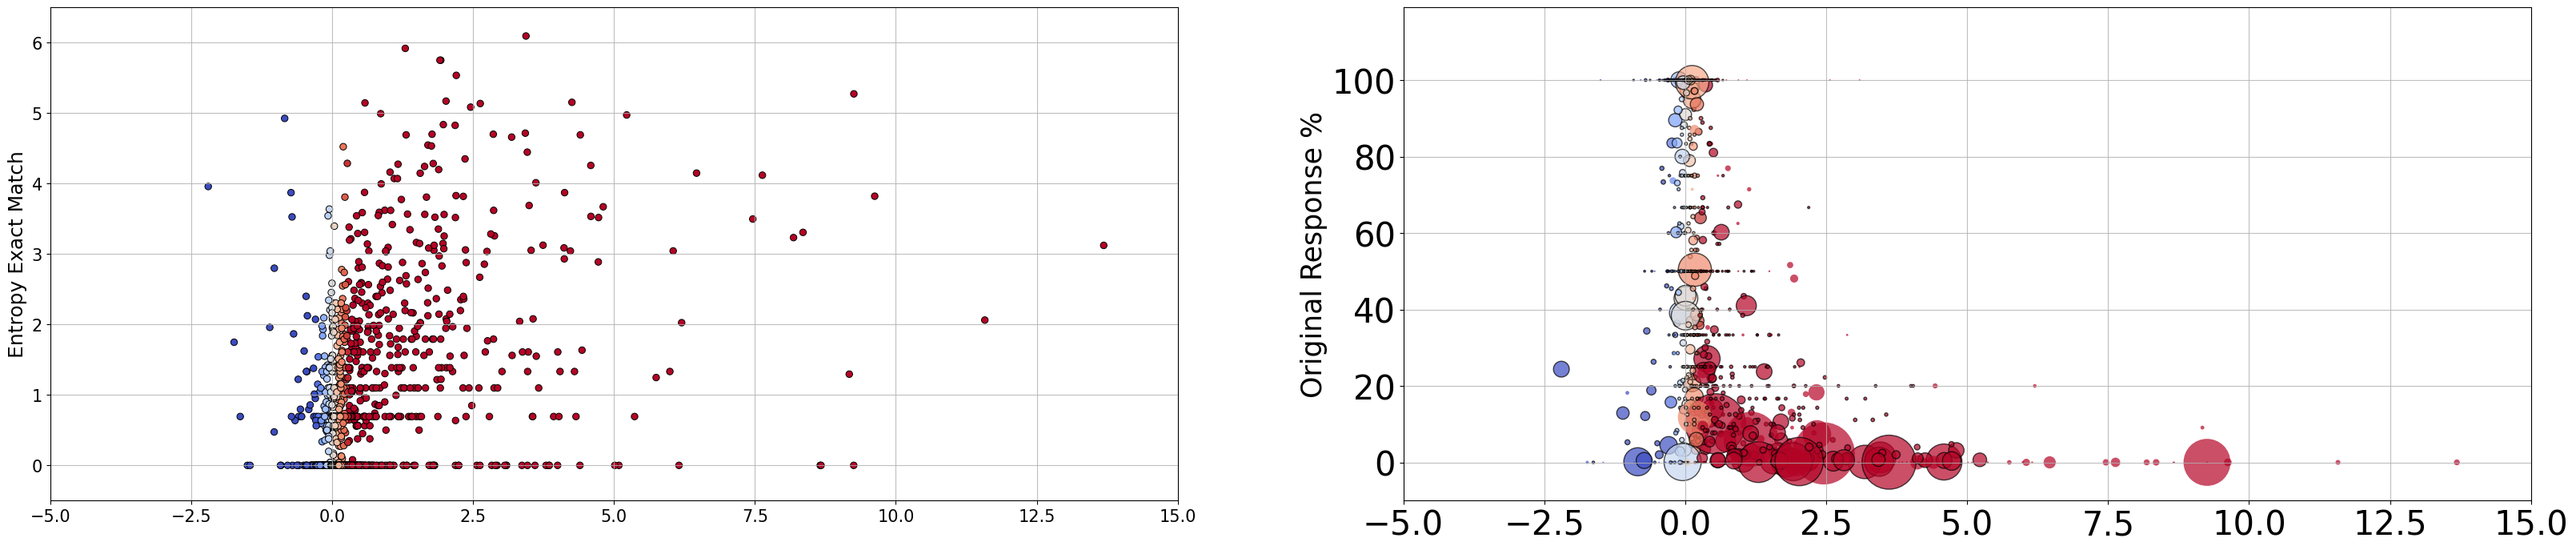

In [32]:
plot_all(all_models)

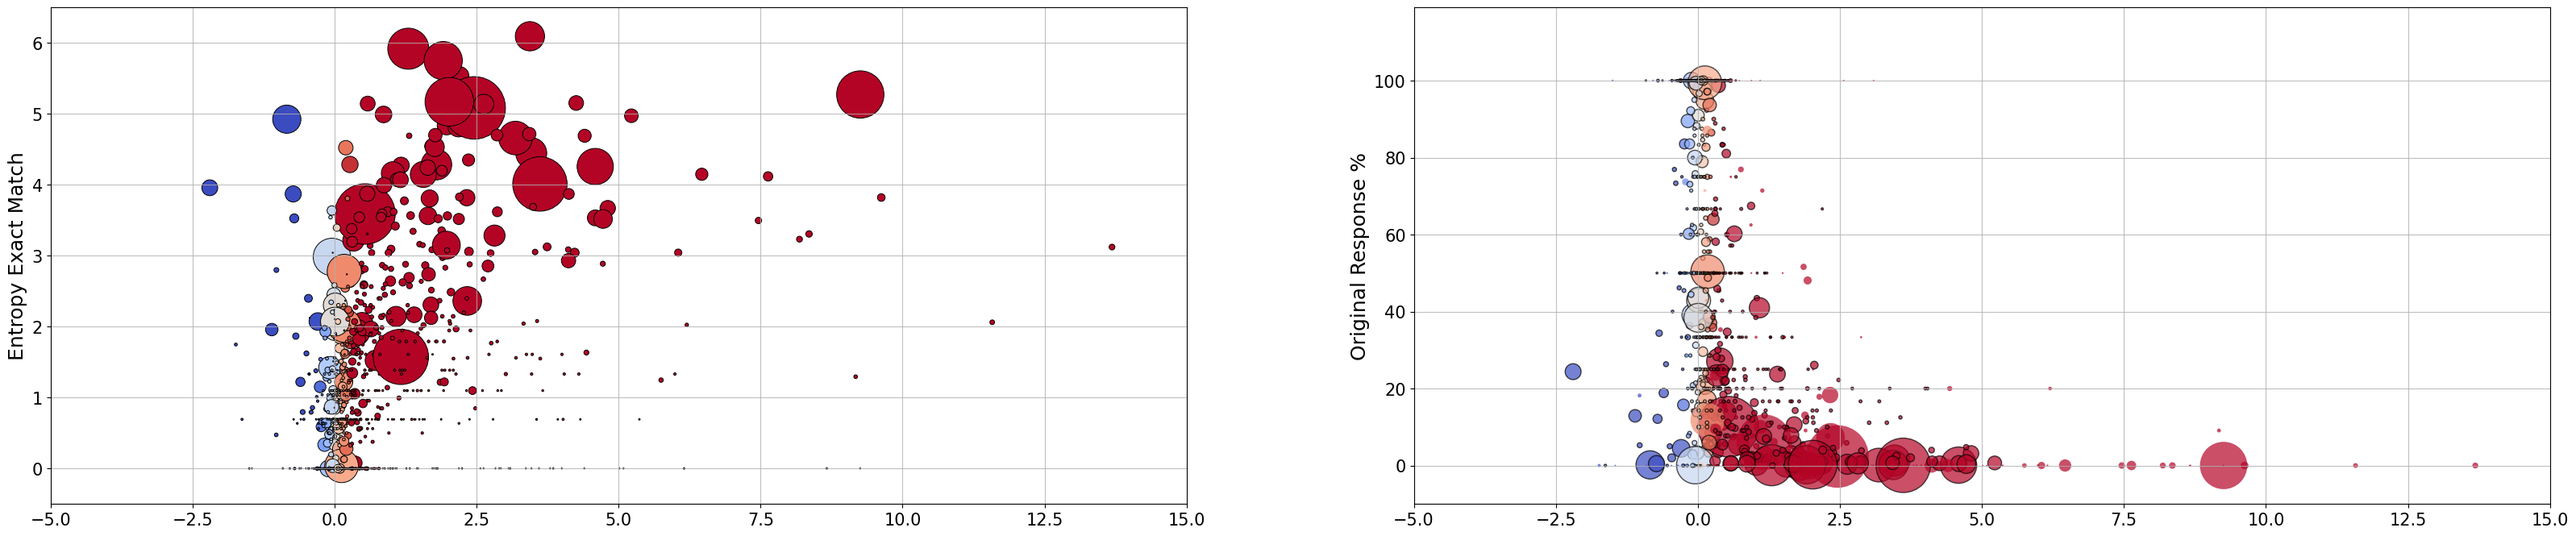

In [49]:
plot_all(all_models)